# 03b — LightGBM Hyperparameter Tuning (Optuna)

Deliberate hyperparameter search over the project's best model (LightGBM, untuned test AP 0.9211). We optimise **validation** average precision with Optuna (TPE, 40 trials), refit the best params, and evaluate on the frozen test split using an F2 threshold tuned on val. Logged as `lightgbm_tfidf_svd_meta_tuned` alongside — not replacing — the untuned row, so the experiments table shows the effect of tuning.

In [2]:
# === Install Optuna (03b only) ===
# Optuna isn't preinstalled in Colab. We pin numpy to the version already loaded so
# pip can't upgrade/downgrade it
import numpy, subprocess
subprocess.run(
    ["pip", "install", "-q", "optuna", f"numpy=={numpy.__version__}"],
    check=True,
)

# Verify: Optuna present, numpy untouched, LightGBM still imports (ABI intact).
import importlib, optuna
importlib.import_module("lightgbm")
print("optuna:", optuna.__version__)
print("numpy :", numpy.__version__, "(pinned, unchanged)")
print("lightgbm import: OK")

optuna: 4.9.0
numpy : 2.0.2 (pinned, unchanged)
lightgbm import: OK


In [3]:
import sys
from pathlib import Path

# Make `src` importable whether this runs from notebooks/ or the project root.
ROOT = Path.cwd()
if not (ROOT / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
from sklearn.metrics import average_precision_score

from src import config, evaluation, features, models, preprocessing

config.set_seed()
config.ensure_dirs()
pd.set_option("display.width", 120)

## Load and preprocess

Same splits and same feature pipeline as notebook 03 (`scale_numeric=False`), so the tuned run differs from the untuned baseline only in hyperparameters.

In [4]:
train, val, test = preprocessing.load_splits()

# Fit every transformer on train only, then reuse them - no refitting on val/test
X_train, y_train, artifacts = preprocessing.preprocess_data(train, scale_numeric=False)
X_val, y_val = preprocessing.preprocess_new_data(val, artifacts)
X_test, y_test = preprocessing.preprocess_new_data(test, artifacts)

print(f"X_train {X_train.shape} | X_val {X_val.shape} | X_test {X_test.shape}")
print(f"{config.SVD_COMPONENTS} SVD text components + "
      f"{X_train.shape[1] - config.SVD_COMPONENTS - len(features.NUMERIC_FEATURES)} one-hot + "
      f"{len(features.NUMERIC_FEATURES)} hand-crafted")

X_train (12319, 424) | X_val (2640, 424) | X_test (2640, 424)
200 SVD text components + 190 one-hot + 34 hand-crafted


## Optuna search

In [5]:
import optuna

optuna.logging.set_verbosity(optuna.logging.WARNING)


def objective(trial):
    # Copy defaults so objective/verbose/random_state survive; tune only the tree
    # structure + regularisation. n_estimators stays 1000
    params = dict(config.LIGHTGBM_PARAMS)
    params.update({
        "num_leaves": trial.suggest_int("num_leaves", 15, 255),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 100),
        "subsample": trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-3, 10.0, log=True),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-3, 10.0, log=True),
    })
    model = models.train_lightgbm(X_train, y_train, X_val, y_val, params=params)
    proba_val = models.predict_proba(model, X_val)
    return average_precision_score(y_val, proba_val)  # primary metric = val AP


def _log_trial(study, trial):
    print(f"trial {trial.number:2d}: val AP {trial.value:.4f} | best {study.best_value:.4f}")


study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=config.SEED),
)
study.optimize(objective, n_trials=40, callbacks=[_log_trial])

print(f"\nbest val AP: {study.best_value:.4f}")
print("best params:", study.best_params)

trial  0: val AP 0.9031 | best 0.9031
trial  1: val AP 0.9189 | best 0.9189
trial  2: val AP 0.9194 | best 0.9194
trial  3: val AP 0.9257 | best 0.9257
trial  4: val AP 0.9011 | best 0.9257
trial  5: val AP 0.9079 | best 0.9257
trial  6: val AP 0.9171 | best 0.9257
trial  7: val AP 0.8955 | best 0.9257
trial  8: val AP 0.9187 | best 0.9257
trial  9: val AP 0.9118 | best 0.9257
trial 10: val AP 0.9132 | best 0.9257
trial 11: val AP 0.9129 | best 0.9257
trial 12: val AP 0.9205 | best 0.9257
trial 13: val AP 0.9163 | best 0.9257
trial 14: val AP 0.9044 | best 0.9257
trial 15: val AP 0.9248 | best 0.9257
trial 16: val AP 0.9282 | best 0.9282
trial 17: val AP 0.9266 | best 0.9282
trial 18: val AP 0.9275 | best 0.9282
trial 19: val AP 0.9131 | best 0.9282
trial 20: val AP 0.9220 | best 0.9282
trial 21: val AP 0.9288 | best 0.9288
trial 22: val AP 0.9129 | best 0.9288
trial 23: val AP 0.9147 | best 0.9288
trial 24: val AP 0.8696 | best 0.9288
trial 25: val AP 0.9296 | best 0.9296
trial 26: va

## Search diagnostics

/tmp/ipykernel_1212/2642201278.py:7: ExperimentalWarning: optuna.visualization.matplotlib._optimization_history.plot_optimization_history is experimental (supported from v2.2.0). The interface can change in the future.
  plot_optimization_history(study)


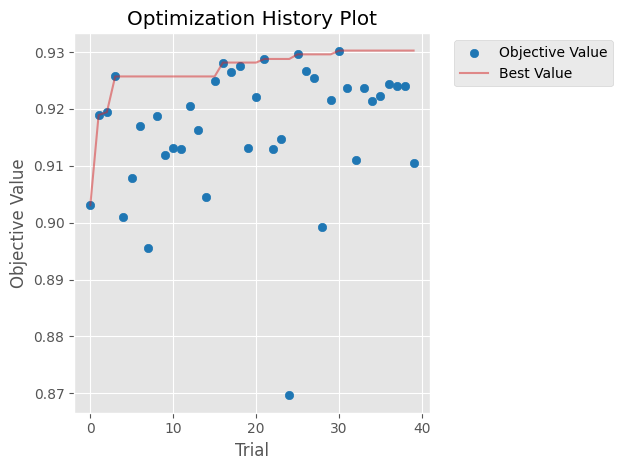

/tmp/ipykernel_1212/2642201278.py:11: ExperimentalWarning: optuna.visualization.matplotlib._param_importances.plot_param_importances is experimental (supported from v2.2.0). The interface can change in the future.
  plot_param_importances(study)


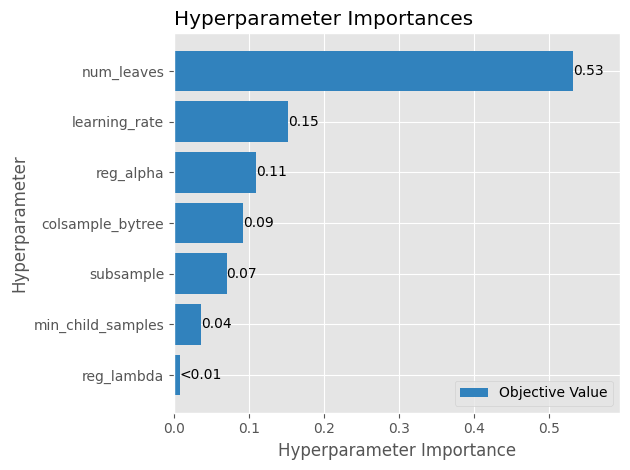

In [6]:
import matplotlib.pyplot as plt
from optuna.visualization.matplotlib import (
    plot_optimization_history,
    plot_param_importances,
)

plot_optimization_history(study)
plt.tight_layout()
plt.show()

plot_param_importances(study)
plt.tight_layout()
plt.show()

### Search diagnostics

The best val AP reaches the default's neighbourhood by trial 3 (0.926), inches to **0.9303** by trial 30, then plateaus for the final 10 trials — 40 trials was enough to explore the space without stalling early.

`num_leaves` dominates the importance plot (**0.53** — over half the variance in val AP), `learning_rate` a distant second (0.15). Crucially its optimum (72) sits close to the default (63): the highest-leverage knob was **already well set**, which is exactly why the overall gain is small. `reg_alpha` (0.11) matters only in that raising L1 hurts — the best keeps it near zero; `reg_lambda`, `min_child_samples` and the sampling ratios carry little leverage (≤0.07).

Note: `min_child_samples` drifted furthest from its default (20 → 79) yet ranks near the bottom for importance. "Deviated most" is not "mattered most" — fANOVA importance measures how much varying a knob moves the score, not how far the best value drifted.

This describes the search over **val**. Whether tuning actually helps is decided on **test**, next.

## Refit best params and evaluate on test

Refit LightGBM with Optuna's best config, then judge it on the frozen test split. The F2 threshold is tuned on val and frozen on test — the same protocol as every other model, so the comparison against untuned (test AP 0.9211) is apples-to-apples.

In [7]:
best = dict(config.LIGHTGBM_PARAMS)
best.update(study.best_params)
final = models.train_lightgbm(X_train, y_train, X_val, y_val, params=best)

proba_val = models.predict_proba(final, X_val)
proba_test = models.predict_proba(final, X_test)

best_threshold, best_f2 = evaluation.tune_threshold(y_val, proba_val, beta=2.0)

val_metrics = evaluation.evaluate_predictions(y_val, proba_val, best_threshold)
test_metrics = evaluation.evaluate_predictions(y_test, proba_test, best_threshold)

compare = pd.DataFrame({"val": val_metrics, "test": test_metrics}).T
compare = compare[["average_precision", "roc_auc", "precision", "recall", "f1"]]

tuned_ap = test_metrics["average_precision"]
print(f"trees kept by early stopping: {final.best_iteration_}")
print(f"F2 threshold from val: {best_threshold:.4f}  (val F2 {best_f2:.4f}, frozen on test)")
print(f"untuned test AP 0.9211  ->  tuned {tuned_ap:.4f}  (delta {tuned_ap - 0.9211:+.4f})")
compare.round(4)

trees kept by early stopping: 380
F2 threshold from val: 0.1159  (val F2 0.8741, frozen on test)
untuned test AP 0.9211  ->  tuned 0.9037  (delta -0.0174)


,average_precision,roc_auc,precision,recall,f1
val,0.9303,0.9944,0.7239,0.9219,0.8110
test,0.9037,0.9883,0.7208,0.8672,0.7872


In [11]:
# Log both rows in-notebook via log_experiment
evaluation.log_experiment("lightgbm_tfidf_svd_meta_tuned", val_metrics, split="val",
                          notes="Optuna 40 trials TPE F2-tuned")
evaluation.log_experiment("lightgbm_tfidf_svd_meta_tuned", test_metrics, split="test",
                          notes="threshold frozen from val")

# Test predictions for the Phase-6 shared PR curve (same format as every other model).
models.save_test_predictions("lightgbm_tfidf_svd_meta_tuned", y_test, proba_test)

# Verify at once - append-only file, so a second run would duplicate. Must read 13 rows.
check = pd.read_csv(config.EXPERIMENTS_CSV)
print("rows:", len(check), "| nan in model:", check["model"].isna().sum())
print([m for m in check["model"] if "_tuned" in str(m)])

Saved /content/Fake_Job_Postings_Detection/models/predictions_lightgbm_tfidf_svd_meta_tuned_test.csv
rows: 15 | nan in model: 0
['lightgbm_tfidf_svd_meta_tuned', 'lightgbm_tfidf_svd_meta_tuned', 'lightgbm_tfidf_svd_meta_tuned', 'lightgbm_tfidf_svd_meta_tuned']


## Conclusions

Tuning did **not** beat the default. Optuna's best config scored val AP **0.9303** (above untuned val 0.920) but only **0.9037** on test — below untuned's **0.9211** (delta −0.017). The untuned model stays the project's best; both rows are kept in `experiments.csv` so the table tells the truth.

Why it didn't help:
- **Validation overfit.** Untuned val→test was flat (0.920 → 0.921). Tuned opened a 0.027 gap (0.930 → 0.904): Optuna maximised val AP over 40 trials and picked the val winner, which didn't carry to held-out test. Val was "spent" three times (early stopping, trial selection, threshold), so its score is optimistic by design — test is the honest judge.
- **The high-leverage knob was already set.** `num_leaves` alone explains 53% of the val-AP variance, and its optimum (72) sits next to the default (63). With no room to win on the one knob that matters, the search "won" on low-leverage knobs by chasing val noise that didn't generalise. On ~128 test positives some of the −0.017 is noise, but the direction (val↑ / test↓) is overfit, not just noise.

Takeaway: **LightGBM's defaults were already near the ceiling for this dataset; a 40-trial sweep confirmed that rather than beating it.** This is exactly why models are ranked on a held-out test split, never on the validation set they were tuned against.